In [21]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt 
# import openseespy.postprocessing.Get_Rendering as opsplt

In [22]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *  

In [23]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to C:\Users\Michael 
Ocampo\Documents\mini\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [24]:
convert_tcl = 'no'
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='create.tcl',
                output_file='create',
                prefix="ops")

In [25]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (135245122075)>


In [26]:
# User-defined variables
accMul = 7
massDen = 2.0
massProportionalDamping = 0.0
stiffnessProportionalDamping = 0.001
fangle = 31.40
ptangle = 26.50
E = 90000.0
poisson = 0.40
G = E / (2 * (1 + poisson))
B = E / (3 * (1 - 2 * poisson))
press = 0.0
deltaT = 0.010
numSteps = 2000
gamma = 0.500
period = 1
pi = math.pi
inclination = 4
unitWeightX = massDen * 9.81 * math.sin(inclination / 180.0 * pi)
unitWeightY = -massDen * 9.81 * math.cos(inclination / 180.0 * pi)

ops.wipe()
ops.model('basic', '-ndm', 2, '-ndf', 2)

ops.nDMaterial('PressureDependMultiYield', 2, 2, massDen, G, B, fangle, 0.1, 80, 0.5,
                ptangle, 0.17, 0.4, 10, 0.0, 0.015, 1.0)

ops.node(1, 0.0, 0.0)
ops.node(2, 1.0, 0.0)
ops.node(3, 1.0, 1.0)
ops.node(4, 0.0, 1.0)

ops.element('quad', 1, 1, 2, 3, 4, 1.0, 'PlaneStrain', 2, press, 0.0, unitWeightX, unitWeightY)

ops.updateMaterialStage('-material', 2, '-stage', 0)

ops.fix(1, 1, 1)
ops.fix(2, 1, 1)
ops.equalDOF(3, 4, 1, 2)

ops.system('ProfileSPD')
ops.test('NormDispIncr', 1e-12, 25, 0)
ops.constraints('Transformation')
ops.integrator('LoadControl', 1, 1, 1, 1)
ops.algorithm('Newton')
ops.numberer('RCM')
ops.analysis('Static')
ops.analyze(2)

newBulk = G * 2 / 3
# --- switch the material to plastic ---
# switch material in Python

ops.parameter(1001, 'element', 1, "bulkModulus", '2')

ops.updateMaterialStage('-material', 2, '-stage', 1)
ops.updateParameter(1001, newBulk) 

ops.analyze(1)


0

In [27]:
ops.printModel()

Current Domain Information
	Current Time: 3
	Committed Time: 3
NODE DATA: NumNodes: 4

numComponents: 4

 Node: 1
	Coordinates  : 0 0 
	Disps: 0 0 
	 unbalanced Load: 0 0 
	ID : -1 -1 


 Node: 2
	Coordinates  : 1 0 
	Disps: 0 0 
	 unbalanced Load: 0 0 
	ID : -1 -1 


 Node: 3
	Coordinates  : 1 1 
	Disps: 2.12897e-05 -5.07428e-05 
	 unbalanced Load: 0 0 
	ID : 0 1 


 Node: 4
	Coordinates  : 0 1 
	Disps: 2.12897e-05 -5.07428e-05 
	 unbalanced Load: 0 0 
	ID : 0 1 

ELEMENT DATA: NumEle: 1

numComponents: 1

FourNodeQuad, element id:  1
	Connected external nodes:  1 2 3 4 
	thickness:  1
	surface pressure:  0
	mass density:  0
	body forces:  1.36862 -19.5722
PressureDependMultiYield - loadSatge: 1
	Stress (xx yy xy)
		Gauss point 1: -6.52407 -9.7861 0.684311 
		Gauss point 2: -6.52407 -9.7861 0.684311 
		Gauss point 3: -6.52407 -9.7861 0.684311 
		Gauss point 4: -6.52407 -9.7861 0.684311 

SP_Constraints: numConstraints: 4

numComponents: 4
SP_Constraint: 0	 Node: 1 DOF: 1 ref value: 0 

In [28]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [29]:
ops.setTime(0.0)
ops.wipeAnalysis()

# --- pattern for dynamic loading ---
ops.timeSeries('Sine', 1, 0.0, 10.0, period, "-factor", accMul)
ops.pattern("UniformExcitation", 1, 1, "-accel",1)

ops.constraints('Transformation')
ops.test('NormDispIncr', 1e-12, 25, 0)
ops.algorithm('Newton')
ops.numberer('RCM')
ops.system('ProfileSPD')
ops.rayleigh(massProportionalDamping, 0.0, stiffnessProportionalDamping, 0.0)
ops.integrator('Newmark', gamma, ((gamma + 0.5) ** 2) / 4)
ops.analysis('VariableTransient')

ops.recorder('Node', '-file', 'gdisp.out', '-time', '-node', 1, 2, 3, 4, '-dof', 1, 2, '-dT', 0.01, 'disp')
ops.recorder('Node', '-file', 'gacce.out', '-time', '-node', 1, 2, 3, 4, '-dof', 1, 2, '-dT', 0.01, 'accel')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'gstress1.out', '-dT', 0.01, 'material', 1, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'gstrain1.out', '-dT', 0.01, 'material', 1, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'gstress3.out', '-dT', 0.01, 'material', 3, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'gstrain3.out', '-dT', 0.01, 'material', 3, 'strain')

startT = tt.time()
ops.analyze(numSteps, deltaT, deltaT / 100, deltaT, 10)
endT = tt.time()
print(f"Execution time: {endT - startT} seconds.")

ops.wipe()

Execution time: 0.17286944389343262 seconds.


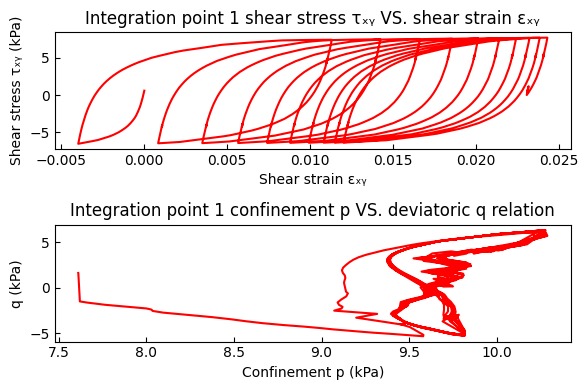

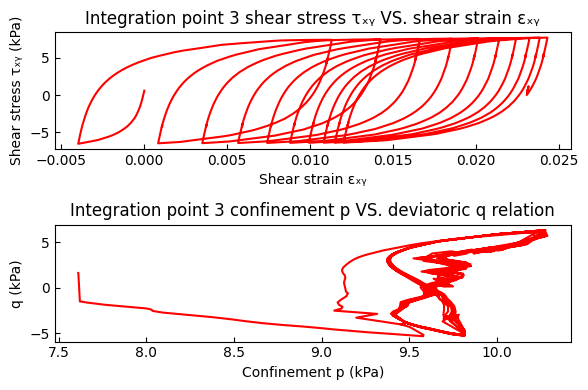

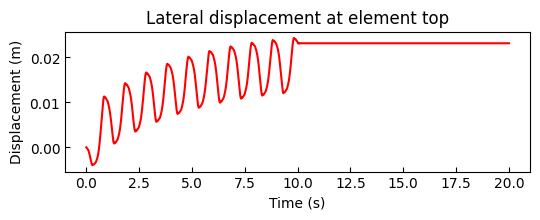

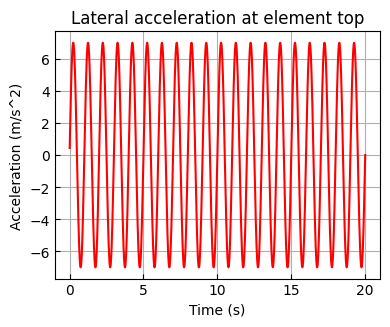

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
a1 = np.loadtxt('gacce.out')
d1 = np.loadtxt('gdisp.out')
s1 = np.loadtxt('gstress1.out')
e1 = np.loadtxt('gstrain1.out')
s5 = np.loadtxt('gstress3.out')
e5 = np.loadtxt('gstrain3.out')

# Approximate MATLAB paperposition as figure size
fs = [0., 0.2, 4, 6]
figsize = (6, 4)

def compute_p_q(stress):
    """Compute confinement p (po) and deviatoric stress q (qo)."""
    po = np.mean(stress[:, 1:4], axis=1)
    qo = []
    for i in range(len(stress)):
        q = ((stress[i,1] - stress[i,2])**2 +
             (stress[i,2] - stress[i,3])**2 +
             (stress[i,1] - stress[i,3])**2 +
             6.0 * stress[i,4]**2)
        q = np.sign(stress[i,4]) * (1/3.0) * np.sqrt(q)
        qo.append(q)
    return po, np.array(qo)

# --- Integration Point 1 ---
po1, qo1 = compute_p_q(s1)

plt.figure(1, figsize=figsize)
plt.clf()
plt.subplot(2,1,1)
plt.plot(e1[:,3], s1[:,4], 'r')
plt.title('Integration point 1 shear stress τₓᵧ VS. shear strain εₓᵧ')
plt.xlabel('Shear strain εₓᵧ')
plt.ylabel('Shear stress τₓᵧ (kPa)')

plt.subplot(2,1,2)
plt.plot(-po1, qo1, 'r')
plt.title('Integration point 1 confinement p VS. deviatoric q relation')
plt.xlabel('Confinement p (kPa)')
plt.ylabel('q (kPa)')

plt.tight_layout()
plt.savefig('SS_PQ1.jpg')
plt.show()

# --- Integration Point 3 ---
po3, qo3 = compute_p_q(s5)

plt.figure(4, figsize=figsize)
plt.clf()
plt.subplot(2,1,1)
plt.plot(e5[:,3], s5[:,4], 'r')
plt.title('Integration point 3 shear stress τₓᵧ VS. shear strain εₓᵧ')
plt.xlabel('Shear strain εₓᵧ')
plt.ylabel('Shear stress τₓᵧ (kPa)')

plt.subplot(2,1,2)
plt.plot(-po3, qo3, 'r')
plt.title('Integration point 3 confinement p VS. deviatoric q relation')
plt.xlabel('Confinement p (kPa)')
plt.ylabel('q (kPa)')

plt.tight_layout()
plt.savefig('SS_PQ5.jpg')
plt.show()

# --- Displacement ---
plt.figure(2, figsize=figsize)
plt.clf()
plt.subplot(2,1,1)
plt.plot(d1[:,0], d1[:,5], 'r')  # MATLAB col 6 → Python col index 5
plt.title('Lateral displacement at element top')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')

# --- 5. Plotting acceleration data ---
plt.figure(3, figsize=(fs[2], fs[3]))
plt.clf()

# Interpolate the sine wave. The time range is now 0:0.01:20 and the sine wave is
# calculated for 0:pi/50:40*pi. The `interp1` function in MATLAB handles this implicitly.
# In NumPy, we create the source and destination arrays and then use np.interp.
t_sine_source = np.arange(0, 40.01, 0.01) # a slightly different approach to match interp1
s_wave = accMul * np.sin(np.arange(0, 40*np.pi + 1e-9, np.pi/50))

s_interpolated = np.interp(a1[:, 0], t_sine_source[:len(s_wave)], s_wave)

# Plotting the acceleration
plt.subplot(2, 1, 1)
plt.plot(a1[:, 0], s_interpolated + a1[:, 4], 'r')
plt.title('Lateral acceleration at element top')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.grid(True)
plt.tight_layout()
plt.savefig('A.jpg', dpi=300)

plt.tight_layout()
plt.savefig('D.jpg')
plt.show()
